In [5]:
from typing_extensions import TypeForm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input,Dense, Embedding, SimpleRNN

In [9]:
import pandas as pd

df = pd.read_csv('/content/SPAM text message 20170820 - Data.csv', encoding='latin-1')

# Adjust column names to 'Message' for text and 'Category' for labels based on the DataFrame structure
song = df['Message'].tolist()
labels = df['Category'].map({'ham': 0, 'spam': 1}).values
labels = np.array(labels)

In [12]:
labels

array([0, 0, 1, ..., 0, 0, 0])

Tokenizing the words

In [14]:
vocab_size = 10000
tokens = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokens.fit_on_texts(song)

In [17]:
seqs = tokens.texts_to_sequences(song)
maxlen = max([len(s) for s in seqs])
X = pad_sequences(seqs, maxlen=maxlen, padding= "post")
y = labels
maxlen

189

In [20]:
X[5000]

array([8572,   50,  679,  358, 8573,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,   

Now, Embeddings of words

In [21]:
embed_size = 128
rnn_units = 64

In [22]:
inputs = Input(shape = (maxlen,), dtype = "int32", name = 'Inputs')
x = Embedding(input_dim= vocab_size, output_dim= embed_size, name = "Embeddings")(inputs)
rnn = SimpleRNN(units= rnn_units, return_sequences= False,return_state=False, name = "RNN")(x)

In [24]:
x_last = rnn
out = Dense(1, activation= "sigmoid", name = "Output")(x_last)

In [25]:
model = Model(inputs = inputs, outputs = out, name = "Simple_RNN")
model.compile(optimizer= "adam", loss= "binary_crossentropy", metrics= ["accuracy"])
model.summary()

Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Inputs (InputLayer)             │ (None, 189)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Embeddings (Embedding)          │ (None, 189, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ RNN (SimpleRNN)                 │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,292,417 (4.93 MB)

 Trainable params: 1,292,417 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
history = model.fit(X, y, epochs=15, batch_size=32, validation_split=0.2)

Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 83ms/step - accuracy: 0.8649 - loss: 0.3968 - val_accuracy: 0.8700 - val_loss: 0.3871
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 85ms/step - accuracy: 0.8649 - loss: 0.3977 - val_accuracy: 0.8700 - val_loss: 0.3915
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 83ms/step - accuracy: 0.8649 - loss: 0.3975 - val_accuracy: 0.8700 - val_loss: 0.3873
Epoch 4/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 81ms/step - accuracy: 0.8661 - loss: 0.3926 - val_accuracy: 0.8673 - val_loss: 0.3892
Epoch 5/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - accuracy: 0.8735 - loss: 0.3735 - val_accuracy: 0.8664 - val_loss: 0.3771
Epoch 6/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 22s 83ms/step - accuracy: 0.8746 - loss: 0.3718 - val_accuracy: 0.8664 - val_loss: 0.3774
Epoch 7/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 83ms/step - accuracy: 0.8737 - loss: 0.3695 - val_accuracy: 0.8637 - val_loss: 0.3802
Epoch 8/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 81ms/step - accuracy: 0.8732 - loss: 0.3696 - 

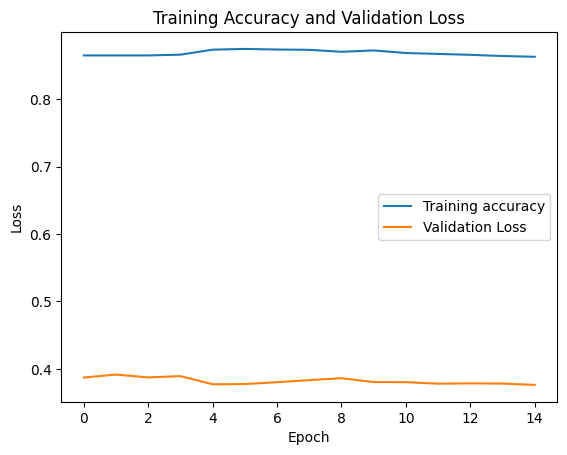

In [32]:
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training Accuracy and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [39]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_proba = model.predict(X)
y_pred = (y_pred_proba > 0.5).astype(int)

cm = confusion_matrix(y_pred, y)
print('Confusion Matrix:')
print(cm)


175/175 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step
Confusion Matrix:
[[4825  747]
 [   0    0]]


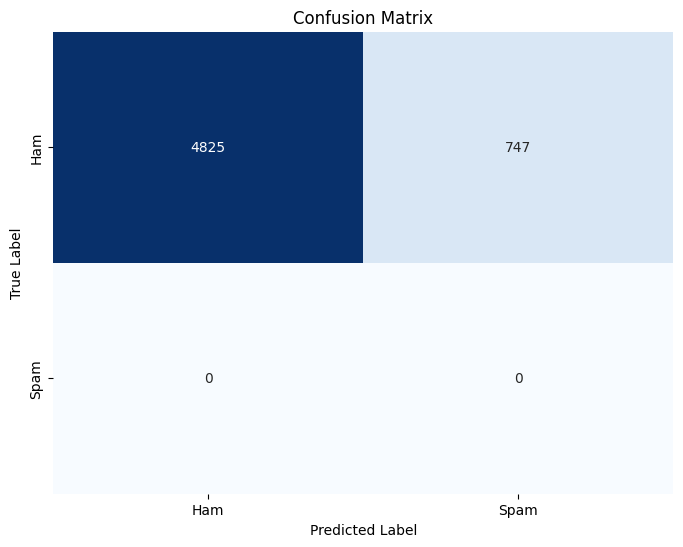

In [40]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [38]:
print('\nClassification Report:')
print(classification_report(y, y_pred, target_names=['Ham', 'Spam']))



Classification Report:
              precision    recall  f1-score   support

         Ham       0.87      1.00      0.93      4825
        Spam       0.00      0.00      0.00       747

    accuracy                           0.87      5572
   macro avg       0.43      0.50      0.46      5572
weighted avg       0.75      0.87      0.80      5572



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [33]:
new_messages = [
    "Congratulations! You've won a free iPhone. Click here to claim your prize!",
    "Hey, how are you doing today? Just checking in.",
    "URGENT: Your bank account has been compromised. Verify your details immediately at this link: http://malicious.link",
    "Can we meet tomorrow to discuss the project?"
]


In [34]:
new_sequences = tokens.texts_to_sequences(new_messages)
new_padded_sequences = pad_sequences(new_sequences, maxlen=maxlen, padding='post')


In [35]:
predictions = model.predict(new_padded_sequences)

for i, message in enumerate(new_messages):
    is_spam = "spam" if predictions[i][0] > 0.5 else "ham"
    print(f"Message: '{message}'")
    print(f"Prediction: {is_spam} (Probability: {predictions[i][0]:.4f})\n")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
Message: 'Congratulations! You've won a free iPhone. Click here to claim your prize!'
Prediction: ham (Probability: 0.1139)

Message: 'Hey, how are you doing today? Just checking in.'
Prediction: ham (Probability: 0.1139)

Message: 'URGENT: Your bank account has been compromised. Verify your details immediately at this link: http://malicious.link'
Prediction: ham (Probability: 0.4583)

Message: 'Can we meet tomorrow to discuss the project?'
Prediction: ham (Probability: 0.1139)

